<a href="https://colab.research.google.com/github/Faith-InsightData/-California-Housing-Data-Analysis-/blob/main/uber_analysis_shan_singh_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
1 ) "uber-raw-data-janjune-15.csv" ->> this data contains all the entries/pickups from 'January' to 'June'
    Quite huge dataset having approx 15M data pts , so lets consider its sample which have approx 1M


2 ) "uber-raw-data-janjune-15_sample.csv" ->> this data is a sample of "uber-raw-data-janjune-15.csv"
    'Since above data is quite huge ~15 Million data pts , hence it is good to work with some sample
     if u do not have good specifications in your systems

'''

1.. Lets Read data for Analysis

In [3]:
### lets import all the necessary packages !

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
import pandas as pd

# The CSV file is directly in the /content/ directory
csv_file_path = '/content/uber-raw-data-janjune-15_sample.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame
df.head()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140


In [7]:
import pandas as pd

# Assuming the file is in the same directory as the notebook, use a relative path
csv_file_path = 'uber-raw-data-janjune-15_sample.csv'

# If the file is in a different directory, provide the correct path relative to
# your notebook or the absolute path on the Linux system
# For example:
# csv_file_path = '/content/Datasets/uber-raw-data-janjune-15_sample.csv'

uber_15 = pd.read_csv(csv_file_path)

In [8]:
uber_15.shape

(100000, 4)

2.. Lets Perform Data pre-processing/Data cleaning !

In [9]:
import pandas as pd

# Assuming you have already loaded the DataFrame into 'uber_15'

# 1. Check Data Types
print("Data Types:\n", uber_15.dtypes)

# 2. Check Missing Values
print("\nMissing Values:\n", uber_15.isnull().sum())

# 3. Check Duplicated Values
print("\nDuplicated Values:\n", uber_15.duplicated().sum())

Data Types:
 Dispatching_base_num    object
Pickup_date             object
Affiliated_base_num     object
locationID               int64
dtype: object

Missing Values:
 Dispatching_base_num       0
Pickup_date                0
Affiliated_base_num     1118
locationID                 0
dtype: int64

Duplicated Values:
 54


In [10]:
print(uber_15.columns)


Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID'],
      dtype='object')


Descriptive Statistics:
          locationID
count  100000.000000
mean      151.922810
std        71.560596
min         2.000000
25%        92.000000
50%       158.000000
75%       230.000000
max       265.000000


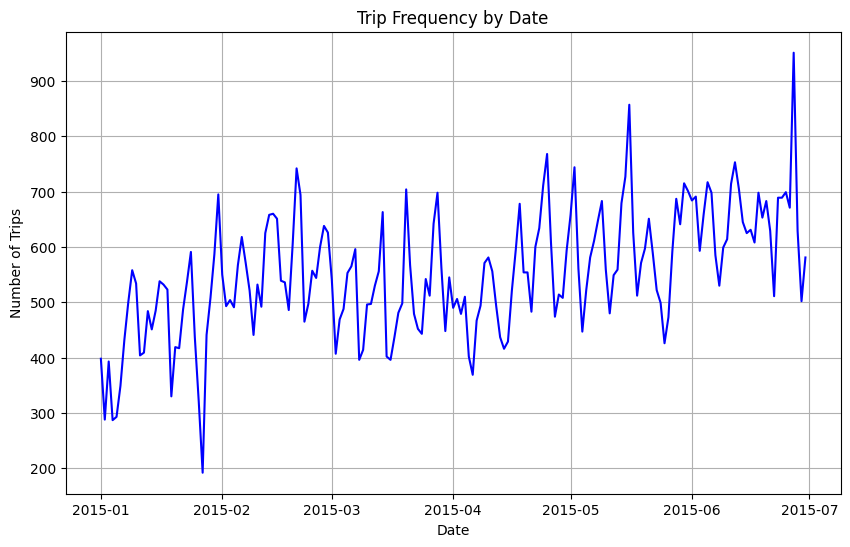

<ipython-input-11-2b4a6bf47366>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dispatching_base_num', data=uber_15, palette='Set2')


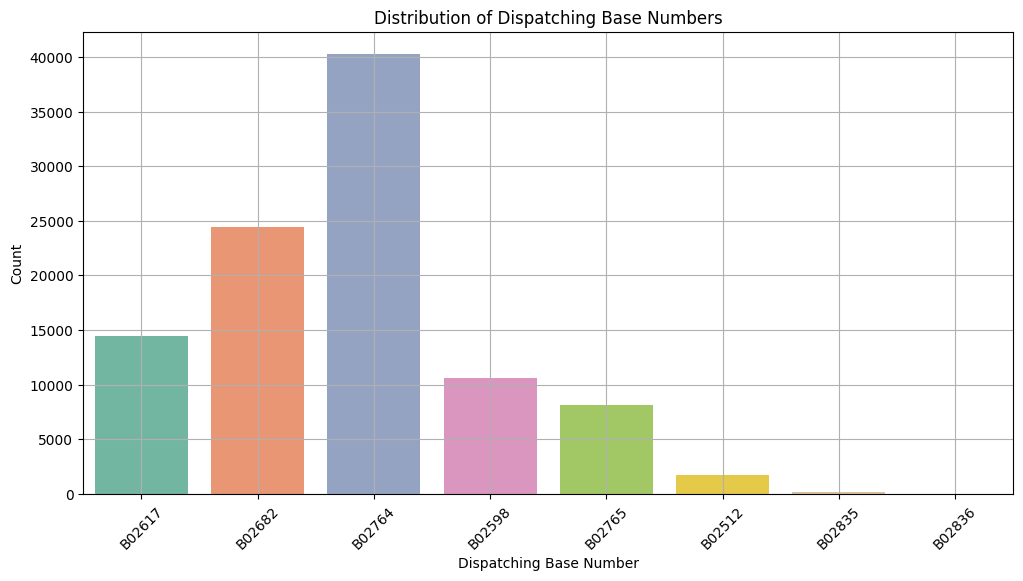

<ipython-input-11-2b4a6bf47366>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Affiliated_base_num', data=uber_15, palette='Set1')


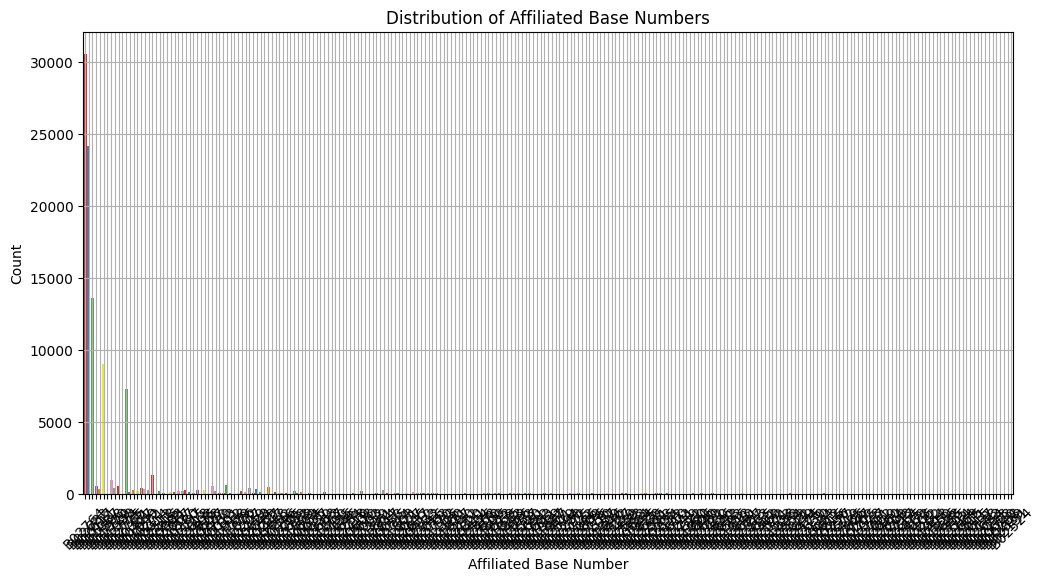

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already loaded the DataFrame into 'uber_15'

# 1. Descriptive Statistics
print("Descriptive Statistics:")
print(uber_15.describe())

# 2. Trip Frequency by Date (using 'Pickup_date' column)
uber_15['Pickup_date'] = pd.to_datetime(uber_15['Pickup_date'])
daily_trips = uber_15.groupby(uber_15['Pickup_date'].dt.date)['locationID'].count()

plt.figure(figsize=(10, 6))
daily_trips.plot(kind='line', color='blue')
plt.title('Trip Frequency by Date')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.grid(True)
plt.show()

# 3. Analysis of Dispatching Base
plt.figure(figsize=(12, 6))
sns.countplot(x='Dispatching_base_num', data=uber_15, palette='Set2')
plt.title('Distribution of Dispatching Base Numbers')
plt.xlabel('Dispatching Base Number')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 4. Affiliated Base Analysis
plt.figure(figsize=(12, 6))
sns.countplot(x='Affiliated_base_num', data=uber_15, palette='Set1')
plt.title('Distribution of Affiliated Base Numbers')
plt.xlabel('Affiliated Base Number')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()




In [ ]:
print(uber_15.head())

  Dispatching_base_num         Pickup_date Affiliated_base_num  locationID
0               B02617 2015-05-02 21:43:00              B02764         237
1               B02682 2015-01-20 19:52:59              B02682         231
2               B02617 2015-03-19 20:26:00              B02617         161
3               B02764 2015-04-10 17:38:00              B02764         107
4               B02764 2015-03-23 07:03:00              B00111         140


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already loaded the DataFrame into 'uber_15'

# 1. Descriptive Statistics
print("Descriptive Statistics:\n", uber_15.describe())

# 2. Distribution of Trip Durations
# Check if 'trip_duration' is the correct column name. If not, replace with the actual name.
# If the column is not present, you need to calculate it from other columns or reload the data.
try:
    plt.figure(figsize=(10, 6))
    sns.histplot(uber_15['trip_duration'], bins=30)  # Replace 'trip_duration' with actual column name if different
    plt.title('Distribution of Trip Durations')
    plt.xlabel('Trip Duration')
    plt.ylabel('Frequency')
    plt.show()
except KeyError:
    print("Column 'trip_duration' not found in the DataFrame. Please check your data or column name.")

# 3. Pickup and Dropoff Locations (assuming you have 'pickup_latitude', 'pickup_longitude', etc.)
# Make sure these columns are present in your DataFrame
try:
    plt.figure(figsize=(12, 8))
    plt.scatter(uber_15['pickup_longitude'], uber_15['pickup_latitude'])  # Replace with actual column names
    plt.title('Pickup Locations')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()
except KeyError as e:
    print(f"Column {e} not found in the DataFrame. Please check your data or column name.") #Fixed the indentation here to be part of the print statement

# 4. Correlation Matrix (for numerical features)
# Update numerical_features with the correct columns from your data
numerical_features = ['trip_duration', 'distance', 'fare', ...]  # Replace with your numerical columns
try:
    correlation_matrix = uber_15[numerical_features].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
except KeyError as e:
    print(f"Column {e} not found in the DataFrame. Please check your data or column name.")


# 5. Trip Frequency by

Descriptive Statistics:
                          Pickup_date     locationID
count                         100000  100000.000000
mean   2015-04-07 08:00:13.338620160     151.922810
min              2015-01-01 00:01:51       2.000000
25%    2015-02-20 21:54:54.249999872      92.000000
50%              2015-04-10 00:15:30     158.000000
75%              2015-05-22 20:14:15     230.000000
max              2015-06-30 23:59:00     265.000000
std                              NaN      71.560596
Column 'trip_duration' not found in the DataFrame. Please check your data or column name.
Column 'pickup_longitude' not found in the DataFrame. Please check your data or column name.
Column "None of [Index(['trip_duration', 'distance', 'fare', Ellipsis], dtype='object')] are in the [columns]" not found in the DataFrame. Please check your data or column name.


<Figure size 1000x600 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [14]:
print(uber_15.columns)

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID'],
      dtype='object')


In [15]:
uber_15 = uber_15.rename(columns={'original_column_name': 'trip_duration'})

In [16]:
uber_15['Pickup_date'][0]

Timestamp('2015-05-02 21:43:00')

In [17]:
type(uber_15['Pickup_date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [18]:
uber_15['Pickup_date'].dtype

dtype('<M8[ns]')

In [19]:
uber_15['Pickup_date'] = pd.to_datetime(uber_15['Pickup_date'])

In [20]:
type(uber_15['Pickup_date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [ ]:
''' datetime64[ns] is a general dtype, while <M8[ns] is a specific dtype , ns is basicaly nano second.. Both are similar , it entirely how your numpy was compiled..

If u want to cross check using Code : np.dtype('datetime64[ns]') == np.dtype('<M8[ns]')

'''

" datetime64[ns] is a general dtype, while <M8[ns] is a specific dtype , ns is basicaly nano second.. Both are similar , it entirely how your numpy was compiled..\n\nIf u want to cross check using Code : np.dtype('datetime64[ns]') == np.dtype('<M8[ns]')\n\n"

In [ ]:
'''
Categorical data has : Object & bool data-types
Numerical data have : Integer & Float data-type


Categorical data refers to a data type that can be stored into groups/categories/labels
Examples of categorical variables are  age group, blood type etc..


Numerical data refers to the data that is in the form of numbers,
Examples of numerical data are height, weight, age etc..

Numerical data has two categories: discrete data and continuous data


Discrete data : It basically takes countable numbers like 1, 2, 3, 4, 5, and so on.
                age of a fly : 8 , 9 day etc..

Continuous data : which is continuous in nature
                  amount of sugar , 11.2 kg  , temp of a city  , your bank balance !



'''

'\nCategorical data has : Object & bool data-types \nNumerical data have : Integer & Float data-type\n\n\nCategorical data refers to a data type that can be stored into groups/categories/labels \nExamples of categorical variables are  age group, blood type etc.. \n\n\nNumerical data refers to the data that is in the form of numbers, \nExamples of numerical data are height, weight, age etc.. \n\nNumerical data has two categories: discrete data and continuous data\n\n\nDiscrete data : It basically takes countable numbers like 1, 2, 3, 4, 5, and so on. \n                age of a fly : 8 , 9 day etc..\n                \nContinuous data : which is continuous in nature \n                  amount of sugar , 11.2 kg  , temp of a city  , your bank balance !\n                  \n\n\n'

In [ ]:
'''

Variations of unsigned integer are : ('uint64','uint32','uint16','uint8') in numpy library..
By the way , all the variations of signed integers comes sub-class numpy.unsignedinteger

uint8 is a 8 bit un-signed integer , it means it can store only positive values
Range->> Integer values from (0 to 255) ie [0 to 2^8 -1]
uint8 has a length of 8 bits (1 bytes).

uint16 is a 16 bit un-signed integer , it means it can store only positive values
Range->> Integer values from (0 to 65535) ie [0 to 2^16 -1]
uint16 has a length of 16 bits (2 bytes).


uint32 is a 32 bit un-signed integer , it means it can store only positive values
Range->> Integer values from (0 to 4294967295) ie [0 to 2^32 -1]
uint32 has a length of 32 bits (4 bytes).


uint64 is a 64 bit un-signed integer , it means it can store only positive values
Range->> Integer values from (0 to 18446744073709551615) ie [0 to 2^64 -1]
uint64 has a length of 64 bits (8 bytes).

'''

"\n\nVariations of unsigned integer are : ('uint64','uint32','uint16','uint8') in numpy library..\nBy the way , all the variations of signed integers comes sub-class numpy.unsignedinteger\n\nuint8 is a 8 bit un-signed integer , it means it can store only positive values\nRange->> Integer values from (0 to 255) ie [0 to 2^8 -1]\nuint8 has a length of 8 bits (1 bytes). \n\nuint16 is a 16 bit un-signed integer , it means it can store only positive values\nRange->> Integer values from (0 to 65535) ie [0 to 2^16 -1]\nuint16 has a length of 16 bits (2 bytes).\n\n\nuint32 is a 32 bit un-signed integer , it means it can store only positive values\nRange->> Integer values from (0 to 4294967295) ie [0 to 2^32 -1]\nuint32 has a length of 32 bits (4 bytes).\n\n\nuint64 is a 64 bit un-signed integer , it means it can store only positive values\nRange->> Integer values from (0 to 18446744073709551615) ie [0 to 2^64 -1]\nuint64 has a length of 64 bits (8 bytes).\n\n"

 Which month have max. Uber pickups in New York City ?

In [21]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140
...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234
99996,B02764,2015-03-06 21:32:00,B02764,24
99997,B02598,2015-03-19 19:56:00,B02598,17
99998,B02682,2015-05-02 16:02:00,B02682,68


In [22]:
uber_15['month'] = uber_15['Pickup_date'].dt.month_name()

In [23]:
uber_15['month']

,month
0,May
1,January
2,March
3,April
4,March
...,...
99995,April
99996,March
99997,March
99998,May


<Axes: xlabel='month'>

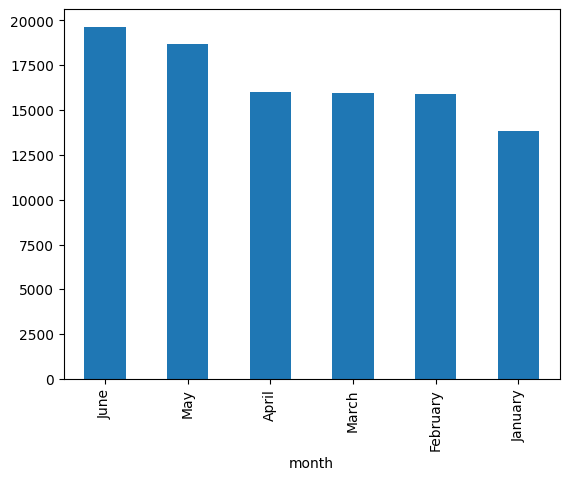

In [24]:
uber_15['month'].value_counts().plot(kind='bar')

In [ ]:
'''
Inference : June seems to have max Uber Pickups

'''

'\nInference : June seems to have max Uber Pickups \n\n'

In [25]:
## extracting dervied features (weekday ,day ,hour ,month ,minute) from 'Pickup_date'..

uber_15['weekday'] = uber_15['Pickup_date'].dt.day_name()
uber_15['day'] = uber_15['Pickup_date'].dt.day
uber_15['hour'] = uber_15['Pickup_date'].dt.hour
uber_15['minute'] = uber_15['Pickup_date'].dt.minute

In [26]:
uber_15.head(4)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,weekday,day,hour,minute
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43
1,B02682,2015-01-20 19:52:59,B02682,231,January,Tuesday,20,19,52
2,B02617,2015-03-19 20:26:00,B02617,161,March,Thursday,19,20,26
3,B02764,2015-04-10 17:38:00,B02764,107,April,Friday,10,17,38


In [27]:
uber_15.head(10)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,weekday,day,hour,minute
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43
1,B02682,2015-01-20 19:52:59,B02682,231,January,Tuesday,20,19,52
2,B02617,2015-03-19 20:26:00,B02617,161,March,Thursday,19,20,26
3,B02764,2015-04-10 17:38:00,B02764,107,April,Friday,10,17,38
4,B02764,2015-03-23 07:03:00,B00111,140,March,Monday,23,7,3
5,B02617,2015-05-03 19:42:00,B02617,87,May,Sunday,3,19,42
6,B02682,2015-01-14 20:21:50,B02764,125,January,Wednesday,14,20,21
7,B02764,2015-05-14 15:52:00,B02764,68,May,Thursday,14,15,52
8,B02617,2015-03-13 21:18:00,B02617,163,March,Friday,13,21,18
9,B02764,2015-06-13 22:12:00,B02682,235,June,Saturday,13,22,12


In [28]:
## pd.crosstab() is used to create pivot table ..

pivot = pd.crosstab(index=uber_15['month'] , columns=uber_15['weekday'])

In [29]:
pivot

weekday,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
month,,,,,,,
April,2366,1834,2512,2056,2826,1880,2521
February,2656,1970,2551,2187,2397,2129,2013
January,2508,1353,2745,1651,2378,1444,1741
June,2794,2852,3037,2488,2770,3191,2504
March,2467,2117,2524,2380,2093,2390,2008
May,3263,1865,3521,2946,2628,2115,2329


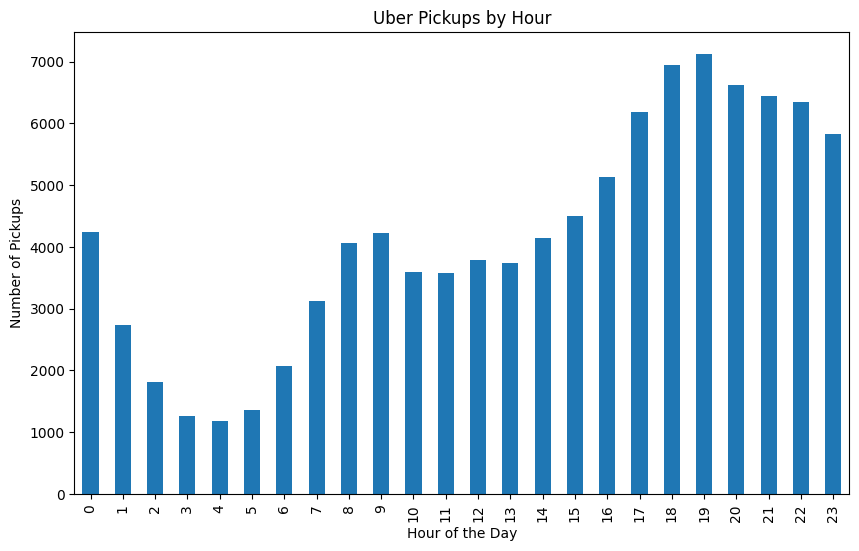

In [30]:
# Group by hour and count pickups
hourly_pickups = uber_15.groupby('hour')['Pickup_date'].count()

# Plotting
hourly_pickups.plot(kind='bar', figsize=(10, 6))
plt.title('Uber Pickups by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Pickups')
plt.show()

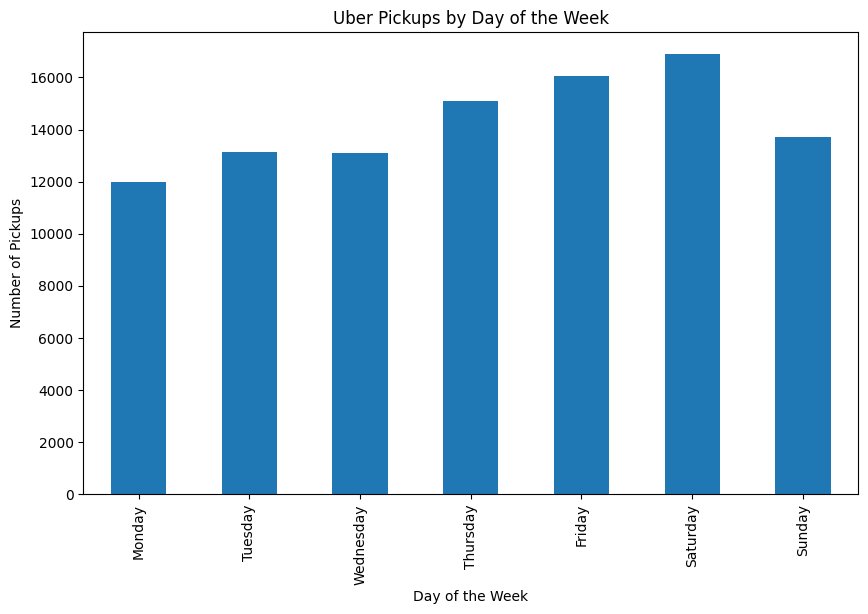

In [31]:
# Group by day of the week and count pickups
daily_pickups = uber_15.groupby('weekday')['Pickup_date'].count()

# Plotting with sorted weekdays
# Define the desired order of weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Sort the daily_pickups Series based on the weekday order
daily_pickups = daily_pickups.reindex(weekday_order)

# Plot the bar chart
daily_pickups.plot(kind='bar', figsize=(10, 6))
plt.title('Uber Pickups by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.show()

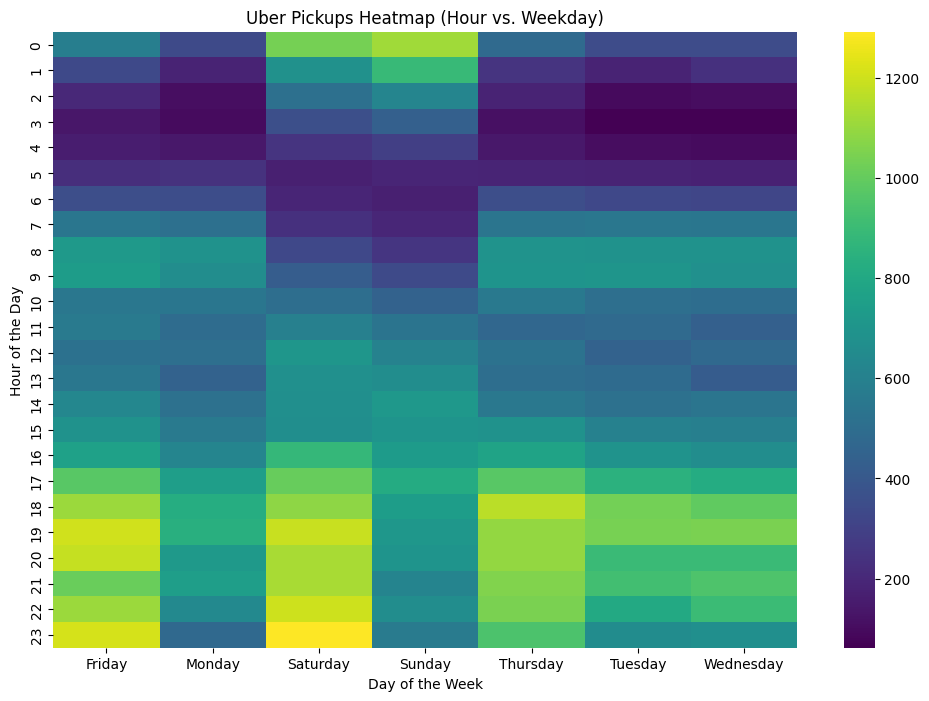

In [32]:
# Create a pivot table for heatmap
heatmap_data = pd.pivot_table(uber_15, values='Pickup_date', index='hour', columns='weekday', aggfunc='count')

# Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Uber Pickups Heatmap (Hour vs. Weekday)')
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.show()

<Axes: xlabel='month'>

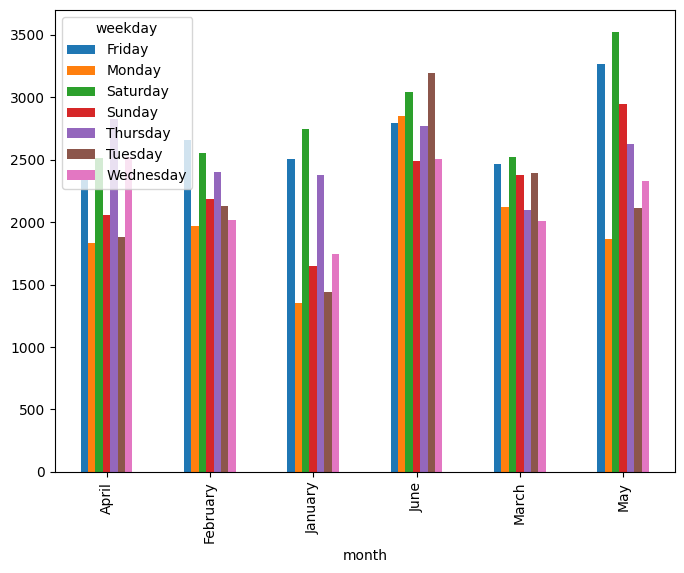

In [33]:
## grouped-bar plot using Pandas ..
pivot.plot(kind='bar' , figsize=(8,6))

'''

On Saturday & Friday, u are getting more Uber pickups in each month , it seems that New Yorkers used to go for
shopping , Malls , fun activities alot on these days

'''

4.. Lets Find out Hourly Rush in New york city on all days

In [34]:
summary = uber_15.groupby(['weekday' , 'hour'] , as_index=False).size()

In [35]:
summary

,weekday,hour,size
0,Friday,0,581
1,Friday,1,333
2,Friday,2,197
3,Friday,3,138
4,Friday,4,161
...,...,...,...
163,Wednesday,19,1044
164,Wednesday,20,898
165,Wednesday,21,949
166,Wednesday,22,900


<Axes: xlabel='hour', ylabel='size'>

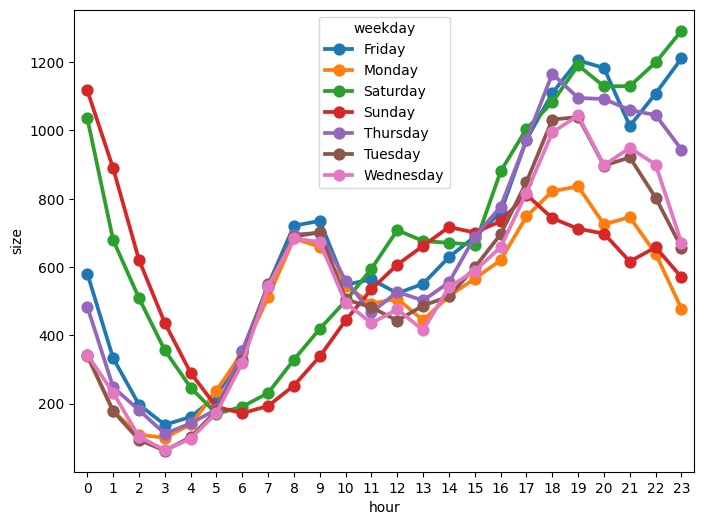

In [36]:
## pointplot between 'hour' & 'size' for all the weekdays..

plt.figure(figsize=(8,6))
sns.pointplot(x="hour" , y="size" , hue="weekday" , data=summary)

In [ ]:
'''
It's interesting to see that Saturday and Sunday exhibit similar demand throughout the late night/morning/afternoon,
but it exhibits opposite trends during the evening. In the evening, Saturday pickups continue to increase throughout the evening,
but Sunday pickups takes a downward turn after evening..

We can see that there the weekdays that has the most demand during the late evening is Friday and Saturday,
which is expected, but what strikes me is that Thursday nights also exhibits very similar trends as Friday and Saturday nights.

It seems like New Yorkers are starting their 'weekends' on Thursday nights. :)


'''

5.. Which Base_number has most number of Active Vehicles ??

In [37]:
uber_15.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'locationID', 'month', 'weekday', 'day', 'hour', 'minute'],
      dtype='object')

In [38]:
import os

# Assuming the file 'uber-raw-data-janjune-15_sample.csv' is in the current working directory
file_path = 'uber-raw-data-janjune-15_sample.csv'

# Check if the file exists in the current working directory
if os.path.exists(file_path):
    # If it exists, list the contents of the file (not the directory as it's a file)
    with open(file_path, 'r') as f:
        # Read and print the first 5 lines of the file to inspect the content
        for i in range(5):
            print(f.readline().strip())
else:
    # If the file is not found, print an informative message
    print(f"Error: File '{file_path}' not found in the current working directory.")
    print("Please make sure the file is in the correct location or provide the full path.")

Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
B02617,2015-05-02 21:43:00,B02764,237
B02682,2015-01-20 19:52:59,B02682,231
B02617,2015-03-19 20:26:00,B02617,161
B02764,2015-04-10 17:38:00,B02764,107


In [39]:
CC

Datasets in the zip file:
Datasets/other-Federal_02216.csv
Datasets/Uber-Jan-Feb-FOIL.csv
Datasets/other-American_B01362.csv
Datasets/other-FHV-services_jan-aug-2015.csv
Datasets/uber-raw-data-janjune-15_sample.csv
Datasets/other-Diplo_B01196.csv
Datasets/other-Dial7_B00887.csv
Datasets/other-Highclass_B01717.csv
Datasets/other-Firstclass_B01536.csv
Datasets/other-Lyft_B02510.csv
Datasets/other-Skyline_B00111.csv
Datasets/other-Carmel_B00256.csv
Datasets/other-Prestige_B01338.csv
Datasets/uber-raw-data-may14.csv
Datasets/uber-raw-data-jul14.csv
Datasets/uber-raw-data-apr14.csv
Datasets/uber-raw-data-sep14.csv
Datasets/uber-raw-data-aug14.csv
Datasets/uber-raw-data-jun14.csv
Datasets/uber-raw-data-janjune-15.csv


In [40]:
import zipfile

# Check the contents of the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    print(zip_ref.namelist())  # Lists all files in the zip archive


['Datasets/other-Federal_02216.csv', 'Datasets/Uber-Jan-Feb-FOIL.csv', 'Datasets/other-American_B01362.csv', 'Datasets/other-FHV-services_jan-aug-2015.csv', 'Datasets/uber-raw-data-janjune-15_sample.csv', 'Datasets/other-Diplo_B01196.csv', 'Datasets/other-Dial7_B00887.csv', 'Datasets/other-Highclass_B01717.csv', 'Datasets/other-Firstclass_B01536.csv', 'Datasets/other-Lyft_B02510.csv', 'Datasets/other-Skyline_B00111.csv', 'Datasets/other-Carmel_B00256.csv', 'Datasets/other-Prestige_B01338.csv', 'Datasets/uber-raw-data-may14.csv', 'Datasets/uber-raw-data-jul14.csv', 'Datasets/uber-raw-data-apr14.csv', 'Datasets/uber-raw-data-sep14.csv', 'Datasets/uber-raw-data-aug14.csv', 'Datasets/uber-raw-data-jun14.csv', 'Datasets/uber-raw-data-janjune-15.csv']


In [41]:
csv_file_path = './Dataset/Uber-Jan-Feb-FOIL.csv'


In [42]:
csv_file_path = '/content/Uber-Jan-Feb-FOIL.csv'

# Load the CSV file into a pandas DataFrame
uber_foil = pd.read_csv(csv_file_path)


In [44]:
import pandas as pd

# Make sure the file path is correct. Update this if the file is located elsewhere.
csv_file_path = '/content/Uber-Jan-Feb-FOIL.csv'  # Correct the path to where your file is located

# Load the CSV file into a pandas DataFrame
try:
    uber_foil = pd.read_csv(csv_file_path)

    # Display the first few rows of the DataFrame
    print(uber_foil.head())  # This prints the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"File not found: {csv_file_path}. Please check the file path and try again.")



  dispatching_base_number      date  active_vehicles  trips
0                  B02512  1/1/2015              190   1132
1                  B02765  1/1/2015              225   1765
2                  B02764  1/1/2015             3427  29421
3                  B02682  1/1/2015              945   7679
4                  B02617  1/1/2015             1228   9537


In [45]:
uber_foil.shape

(354, 4)

In [46]:
uber_foil.head(3)

,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421


In [47]:
### establishing the entire set-up of Plotly..

In [48]:
!pip install chart_studio ## chart_studio provides a web-service for hosting graphs!
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00


In [49]:
import chart_studio.plotly as py
import plotly.graph_objs as go
import plotly.express as px

from plotly.offline import download_plotlyjs , init_notebook_mode , plot , iplot
## iplot() when working in a Jupyter Notebook to display the plot in the notebook.
## U have to do a proper setup of plotly , otherwise plotly plots gets open in a web-browser instead of Jupyter notebook


In [50]:
init_notebook_mode(connected=True)

In [51]:
uber_foil.columns

Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips'], dtype='object')

In [52]:
px.box(x='dispatching_base_number' , y='active_vehicles' , data_frame=uber_foil)

In [53]:
px.box(x='dispatching_base_number' , y='active_vehicles' , data_frame=uber_foil)
df


,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140
...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234
99996,B02764,2015-03-06 21:32:00,B02764,24
99997,B02598,2015-03-19 19:56:00,B02598,17
99998,B02682,2015-05-02 16:02:00,B02682,68


In [54]:
### if u need distribution +  5-summary stats of data , its good to go with violinplot
px.violin(x='dispatching_base_number' , y='active_vehicles' , data_frame=uber_foil)
print = df

In [55]:
### if u need distribution +  5-summary stats of data , its good to go with violinplot
px.violin(x='dispatching_base_number' , y='active_vehicles' , data_frame=uber_foil)


6.. Collect entire data & Make it ready for the Data Analysis..

In [79]:
import zipfile

zip_file_path = "/content/Datasets-20241020T134242Z-001.zip"

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall("/content/extracted")
        print("Extraction complete.")
except FileNotFoundError:
    print(f"File not found: {zip_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


Extraction complete.


In [76]:
del print  # This restores the default print function


In [80]:
import zipfile

# Path to the ZIP file
zip_file_path = "/content/Datasets-20241020T134242Z-001.zip"

try:
    # Open the ZIP file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Get a list of all the files in the ZIP
        all_files = zip_ref.namelist()

        # Print the files
        print("Files in the ZIP file:")
        for file in all_files:
            print(file)

except FileNotFoundError:
    print(f"File not found: {zip_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


Files in the ZIP file:
Datasets/other-Federal_02216.csv
Datasets/Uber-Jan-Feb-FOIL.csv
Datasets/other-American_B01362.csv
Datasets/other-FHV-services_jan-aug-2015.csv
Datasets/uber-raw-data-janjune-15_sample.csv
Datasets/other-Diplo_B01196.csv
Datasets/other-Dial7_B00887.csv
Datasets/other-Highclass_B01717.csv
Datasets/other-Firstclass_B01536.csv
Datasets/other-Lyft_B02510.csv
Datasets/other-Skyline_B00111.csv
Datasets/other-Carmel_B00256.csv
Datasets/other-Prestige_B01338.csv
Datasets/uber-raw-data-may14.csv
Datasets/uber-raw-data-jul14.csv
Datasets/uber-raw-data-apr14.csv
Datasets/uber-raw-data-sep14.csv
Datasets/uber-raw-data-aug14.csv
Datasets/uber-raw-data-jun14.csv
Datasets/uber-raw-data-janjune-15.csv


In [84]:
import zipfile

# Path to the ZIP file
zip_file_path = "/content/Datasets-20241020T134242Z-001.zip"

try:
    # Open the ZIP file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Extract all files
        zip_ref.extractall("/content/extracted")
        print("Extraction complete.")

        # Get a list of all extracted files
        all_files = zip_ref.namelist()

except FileNotFoundError:
    print(f"File not found: {zip_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


# Define the 'files' variable and assign it the list of extracted files
files = all_files

# Now you can use the 'files' variable
# Make sure '/content/uber-raw-data-janjune-15.csv' is present in the list
if '/content/uber-raw-data-janjune-15.csv' in files:
    files.remove('/content/uber-raw-data-janjune-15.csv')
else:
    print("'/content/uber-raw-data-janjune-15.csv' not found in the list of extracted files.")

Extraction complete.
'/content/uber-raw-data-janjune-15.csv' not found in the list of extracted files.


In [86]:
files

['Datasets/other-Federal_02216.csv',
 'Datasets/Uber-Jan-Feb-FOIL.csv',
 'Datasets/other-American_B01362.csv',
 'Datasets/other-FHV-services_jan-aug-2015.csv',
 'Datasets/uber-raw-data-janjune-15_sample.csv',
 'Datasets/other-Diplo_B01196.csv',
 'Datasets/other-Dial7_B00887.csv',
 'Datasets/other-Highclass_B01717.csv',
 'Datasets/other-Firstclass_B01536.csv',
 'Datasets/other-Lyft_B02510.csv',
 'Datasets/other-Skyline_B00111.csv',
 'Datasets/other-Carmel_B00256.csv',
 'Datasets/other-Prestige_B01338.csv',
 'Datasets/uber-raw-data-may14.csv',
 'Datasets/uber-raw-data-jul14.csv',
 'Datasets/uber-raw-data-apr14.csv',
 'Datasets/uber-raw-data-sep14.csv',
 'Datasets/uber-raw-data-aug14.csv',
 'Datasets/uber-raw-data-jun14.csv',
 'Datasets/uber-raw-data-janjune-15.csv']

In [93]:
import os
import pandas as pd
import zipfile

# Create a blank dataframe
final = pd.DataFrame()

# Specify the path to the zip file
zip_path = r"/content/Datasets-20241020T134242Z-001.zip"
extract_path = r"/content/extracted_datasets"

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Get the list of files in the extracted directory
files = os.listdir(extract_path)

# Loop through the files and concatenate the dataframes
for file in files:
    if file.endswith('.csv'):  # Ensure we are reading only CSV files
        current_df = pd.read_csv(os.path.join(extract_path, file))
        final = pd.concat([final, current_df], ignore_index=True)  # Concatenate the dataframes


In [94]:
final.shape

(0, 0)

In [ ]:
### After Collecting entire data ,u might ask is : Do we have duplicate entires in data ?
### We are going to remove duplicates data when the entire row is duplicate

In [95]:
### first lets figure out total observations where we have duplicate values..
final.duplicated().sum()

0

In [97]:
## drop duplicate rows ..
final.drop_duplicates(inplace=True)

""


In [96]:
final.head(3)

""


Dataset Information :
The dataset contains information about the Datetime, Latitude, Longitude and Base of each uber ride that happened in the month of July 2014 at New York City, USA
Date/Time : The date and time of the Uber pickup
Lat : The latitude of the Uber pickup
Lon : The longitude of the Uber pickup
Base : The TLC base company code affiliated with the Uber pickup

In [98]:
The Base codes are for the following Uber bases:
B02512 : Unter
B02598 : Hinter
B02617 : Weiter
B02682 : Schmecken
B02764 : Danach-NY

SyntaxError: invalid syntax (<ipython-input-98-e7ebc8cbbad6>, line 1)

7.. at what locations of New York City we are getting rush ??

In [ ]:
### ie where-ever we have more data-points or more density, it means more rush is at there !

In [103]:
!pip install pandas

import pandas as pd
import zipfile

# Unzip the file
with zipfile.ZipFile('/content/Datasets-20241020T134242Z-001.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/extracted_datasets')

# Load the relevant CSV file into a DataFrame
# Replace 'your_csv_file.csv' with the actual name of your CSV file
file_path = '/content/extracted_datasets/Datasets/Uber-Jan-Feb-FOIL.csv'
final = pd.read_csv(file_path)

# Now you can proceed with your code
# Check if the DataFrame is empty first
if final.empty:

    print = dataframe


In [107]:
print(final.columns)


Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips'], dtype='object')


In [108]:
rush_uber = final.groupby(['dispatching_base_number', 'date'], as_index=False).size()


In [109]:
rush_uber.head(6)

,dispatching_base_number,date,size
0,B02512,1/1/2015,1
1,B02512,1/10/2015,1
2,B02512,1/11/2015,1
3,B02512,1/12/2015,1
4,B02512,1/13/2015,1
5,B02512,1/14/2015,1


In [110]:
!pip install folium

In [111]:
import folium

In [112]:
basemap = folium.Map()

In [113]:
basemap

In [114]:
from folium.plugins import HeatMap

In [117]:
basemap

In [ ]:
We can see a number of hot spots here. Midtown Manhattan is clearly a huge bright spot
& these are made from Midtown to Lower Manhattan followed by Upper Manhattan and the Heights of Brooklyn.

In [ ]:
8.. Examine rush on Hour and Weekday ( Perform Pair wise Analysis )

In [118]:
final.columns

Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips'], dtype='object')

In [119]:
final.head(3)

,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421


In [120]:
final.dtypes

,0
dispatching_base_number,object
date,object
active_vehicles,int64
trips,int64


In [121]:
final.head(3)

,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421


In [122]:
final.dtypes

,0
dispatching_base_number,object
date,object
active_vehicles,int64
trips,int64


In [124]:
# Check the actual column names in your DataFrame.
print(final.columns)

# If the column name is misspelled or has different case, use the correct name:
# Example: If the actual column name is 'date/time'
# final['date/time'][0]

# If the column is not present, you need to create it or load it from your data source.

# If the desired data is in a different column, use that column name instead.
# Example: If the date/time data is in a column called 'Timestamp'
# final['Timestamp'][0]

Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips'], dtype='object')
